# Relapse-Driven Bistability in a Model of Gang Dynamics
## 2. Bifurcation diagrams

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/machyman/kwofie2026relapse/blob/main/notebooks/02_bifurcation_diagrams.ipynb)

Reproduces Figures 3–7 of the companion paper (MBE-8616).

Each diagram sweeps one parameter and solves for **every** feasible equilibrium at each
value, independently, by polynomial root-finding. Nothing is continued from a previous
point, so no branch is lost at a fold.

**What to look for.** In the recruitment diagram, the positive branch turns *backward*
from the threshold: a stable high-gang equilibrium persists for
$\mathcal{R}_0^{\rm simp} < 1$, separated from the gang-free state by a saddle. This is
the paper's central claim — reducing recruitment below the invasion threshold is not
sufficient to eliminate an established gang.

Uses `python/sgr_engine.py`, generated by notebook 01.

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
"""
Bifurcation diagrams for the SGR gang-dynamics model (Figures 3-7).

Author:  James M. Hyman
         Department of Mathematics, Tulane University
         mhyman@tulane.edu
Date:    2026-07-04  Version 1.0
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings, os, sys, json

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
RNG  = np.random.default_rng(SEED)
np.random.seed(SEED)

# ── Plot style ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.size'      : 12,
    'axes.labelsize' : 13,
    'axes.titlesize' : 13,
    'legend.fontsize': 11,
    'figure.dpi'     : 120,
    'lines.linewidth': 1.8,
})

# ── Scale switch ──────────────────────────────────────────────────────────────
# FULL = False  →  quick verification run (well under 5 minutes)
# FULL = True   →  publication-quality run (matches the figures in the paper)
FULL = False
SCALE = dict(n_grid = 500 if FULL else 200)
print(f"Scale: {'FULL (publication)' if FULL else 'QUICK (verification)'}")
print(f"Parameters: {SCALE}")

# ── Repository root (works in Colab and locally) ───────────────────────────────
if not os.path.exists('python'):
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
    elif not os.path.exists('kwofie2026relapse'):
        !git clone -q https://github.com/machyman/kwofie2026relapse.git
        os.chdir('kwofie2026relapse')
os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

# ── The engine (generated by notebook 01; the single definition of the model) ──
sys.path.insert(0, 'python')
from sgr_engine import (Params, ILLUSTRATIVE, replace, equilibria, classify,
                        rhs, jacobian, r0_simp, gstar)
print(f"Working directory: {os.getcwd()}")
print(f"Engine loaded. Baseline R0_simp = {r0_simp(ILLUSTRATIVE):.4f}")

Scale: QUICK (verification)
Parameters: {'n_grid': 200}
Working directory: /mnt/user-data/outputs/kwofie2026relapse
Engine loaded. Baseline R0_simp = 0.9884


## Mathematical verification suite

Each check is a value the paper reports. Two of them are worth stating plainly, because
they are the reason advocacy and deterrence are discussed so carefully in the paper:
at the illustrative baseline, **neither $\epsilon$ nor $\eta$ produces a fold** — acting
alone, neither deterrence nor advocacy closes the bistable interval.

In [2]:
def folds_in(param, lo, hi, n=1200, base=None):
    """Values of `param` where the number of positive equilibria changes (saddle-nodes)."""
    if base is None:
        base = replace(ILLUSTRATIVE, beta_sg=0.855)
    xs, out, prev = np.linspace(lo, hi, n), [], None
    for x in xs:
        p = replace(base, **{param: x})
        npos = sum(1 for (s, g, r) in equilibria(p) if g > 1e-6)
        if prev is not None and npos != prev:
            out.append(float(x))
        prev = npos
    return out


def verification_suite():
    checks, results = [], []
    def check(name, ok): checks.append(name); results.append(bool(ok))

    p = ILLUSTRATIVE
    tc = p.mu + p.gamma
    check("transcritical at beta_sg = mu + gamma = 0.865", abs(tc - 0.865) < 1e-9)

    f_sg = folds_in('beta_sg', 0.02, 1.05)
    check("saddle-node in beta_sg near 0.0757",
          len(f_sg) >= 1 and abs(f_sg[0] - 0.0757) < 5e-3)
    check("bistable interval spans roughly 0.076 < beta_sg < 0.865 (an order of magnitude)",
          len(f_sg) >= 1 and f_sg[0] < 0.1 and tc / f_sg[0] > 8)

    check("saddle-node in relapse beta_rg near 0.8897",
          any(abs(f - 0.8897) < 5e-3 for f in folds_in('beta_rg', 0.0, 3.0)))
    check("saddle-node in reintegration beta_rs near 0.4529",
          any(abs(f - 0.4529) < 5e-3 for f in folds_in('beta_rs', 0.0, 1.0)))

    # Advocacy and deterrence, acting alone, do NOT close the bistable interval.
    check("no fold in advocacy eta over [0, 3] (bistability persists)",
          len(folds_in('eta', 0.0, 3.0)) == 0)
    check("no fold in deterrence eps over [0, 10] (bistability persists)",
          len(folds_in('eps', 0.0, 10.0)) == 0)

    print("Bifurcation verification"); print("-" * 66)
    for name, ok in zip(checks, results):
        print(f"  [{'PASS' if ok else 'FAIL'}]  {name}")
    print("-" * 66)
    print(f"RESULT: {sum(results)}/{len(results)} checks passed.")
    return sum(results), len(results)


N_PASS, N_TOTAL = verification_suite()
assert N_PASS == N_TOTAL, "Bifurcation verification failed."

Bifurcation verification
------------------------------------------------------------------
  [PASS]  transcritical at beta_sg = mu + gamma = 0.865
  [PASS]  saddle-node in beta_sg near 0.0757
  [PASS]  bistable interval spans roughly 0.076 < beta_sg < 0.865 (an order of magnitude)
  [PASS]  saddle-node in relapse beta_rg near 0.8897
  [PASS]  saddle-node in reintegration beta_rs near 0.4529
  [PASS]  no fold in advocacy eta over [0, 3] (bistability persists)
  [PASS]  no fold in deterrence eps over [0, 10] (bistability persists)
------------------------------------------------------------------
RESULT: 7/7 checks passed.


## Implementation: sweeping a parameter

One routine serves every diagram. For each value of the swept parameter we collect all
feasible equilibria and split them by stability, so the plot can draw stable branches
solid and saddle branches dashed, and mark the folds.

In [3]:
def sweep(param, values, base=None):
    """Return {coord: {'stable': (x, y), 'saddle': (x, y)}} over a parameter sweep."""
    if base is None:
        base = replace(ILLUSTRATIVE, beta_sg=0.855)
    data = {c: {'stable': ([], []), 'saddle': ([], [])} for c in 'sgr'}
    for x in values:
        p = replace(base, **{param: x})
        for (s, g, r) in equilibria(p):
            kind = classify((g, r), p)
            if kind not in ('stable', 'saddle'):
                continue
            for c, v in zip('sgr', (s, g, r)):
                data[c][kind][0].append(x)
                data[c][kind][1].append(v)
    return data


LABEL = {'beta_sg': r'recruitment rate $\beta_{sg}$ (week$^{-1}$)',
         'eps'    : r'deterrence $\epsilon$',
         'beta_rg': r'relapse rate $\beta_{rg}$ (week$^{-1}$)',
         'beta_rs': r'reintegration rate $\beta_{rs}$ (week$^{-1}$)',
         'eta'    : r'advocacy effectiveness $\eta$'}


def bifurcation_figure(param, lo, hi, title, fname, mark_threshold=False):
    """Three-panel (s, g, r) bifurcation diagram, annotated as the paper requires."""
    values = np.linspace(lo, hi, SCALE['n_grid'])
    data = sweep(param, values)
    folds = folds_in(param, lo, hi)

    fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.9))
    for ax, c, name in zip(axes, 'sgr', ('susceptible $s$', 'active gang $g$', 'reformed $r$')):
        xs, ys = data[c]['stable']
        ax.plot(xs, ys, '.', color='#1f77b4', ms=2.2, label='stable')
        xs, ys = data[c]['saddle']
        ax.plot(xs, ys, '.', color='#2ca02c', ms=2.2, label='saddle')
        for f in folds:
            ax.plot([f], [np.interp(f, *data[c]['stable'][:2])] if data[c]['stable'][0] else [0],
                    'o', mfc='w', mec='k', ms=7, zorder=5)
        if mark_threshold:
            tc = ILLUSTRATIVE.mu + ILLUSTRATIVE.gamma
            ax.axvline(tc, ls=':', c='k', lw=1.2)
            ax.text(tc, 0.5, r'  $\mathcal{R}_0^{\rm simp}=1$', rotation=90,
                    va='center', fontsize=9)
        ax.set_xlabel(LABEL[param]); ax.set_ylabel(name.split()[-1]); ax.set_title(name)
        ax.grid(alpha=0.25)
    axes[0].legend(loc='center right', markerscale=4)
    fig.suptitle(title, y=1.03)
    fig.tight_layout(); fig.savefig(f'figures/{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  saddle-node(s) at {param} = {[round(f, 4) for f in folds] if folds else 'none'}")
    return folds

## Figure 3 — recruitment: the backward bifurcation

The positive branch bends back from the threshold at
$\beta_{sg} = \mu + \gamma \approx 0.865$ and folds at $\beta_{sg} \approx 0.076$.
Between the fold and the threshold, **three** equilibria coexist: the gang-free state
(stable), a saddle, and a high-gang state (stable). The bistable interval spans an order
of magnitude in $\mathcal{R}_0^{\rm simp}$.

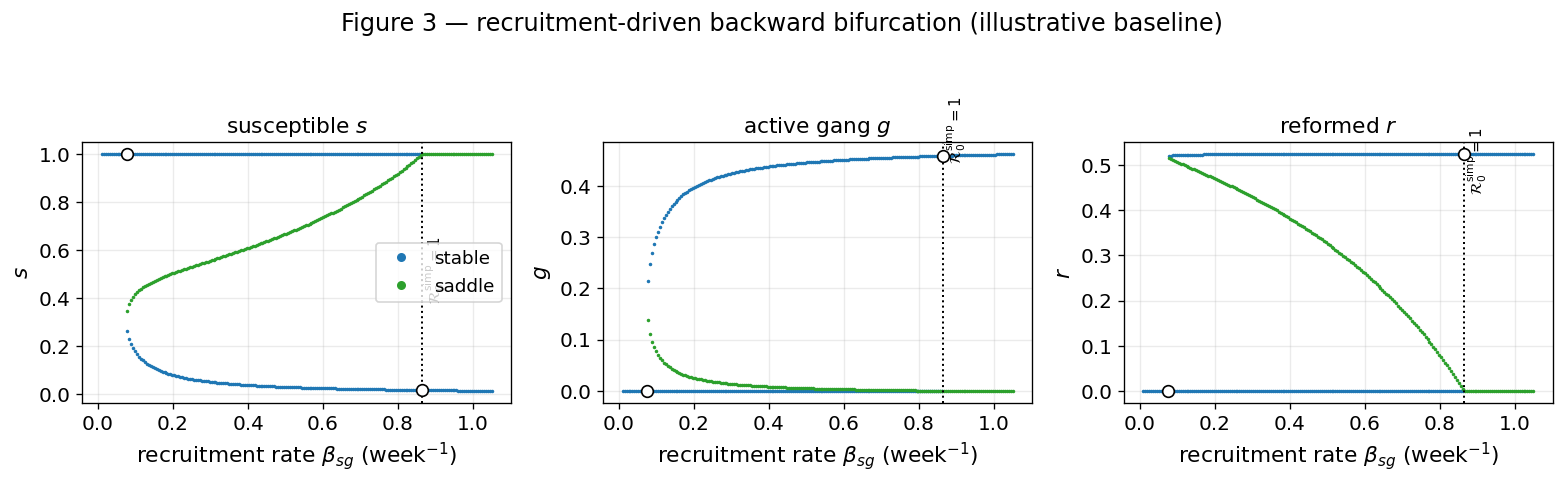

  saddle-node(s) at beta_sg = [0.0759, 0.8652]
  bistable interval: 0.0759 < beta_sg < 0.8650   (R0 from 0.088 to 1.000)


In [4]:
folds_sg = bifurcation_figure(
    'beta_sg', 0.01, 1.05,
    'Figure 3 — recruitment-driven backward bifurcation (illustrative baseline)',
    'fig03_recruitment', mark_threshold=True)
tc = ILLUSTRATIVE.mu + ILLUSTRATIVE.gamma
print(f"  bistable interval: {folds_sg[0]:.4f} < beta_sg < {tc:.4f}"
      f"   (R0 from {folds_sg[0]/tc:.3f} to 1.000)")

## Figures 4–7 — deterrence, relapse, reintegration, advocacy

Each panel fixes the baseline and sweeps one intervention parameter.

Note the asymmetry that the sensitivity analysis in notebook 03 will quantify: relapse
$\beta_{rg}$ and reintegration $\beta_{rs}$ each produce a fold, whereas deterrence
$\epsilon$ and advocacy $\eta$ do **not** close the bistable interval on their own.

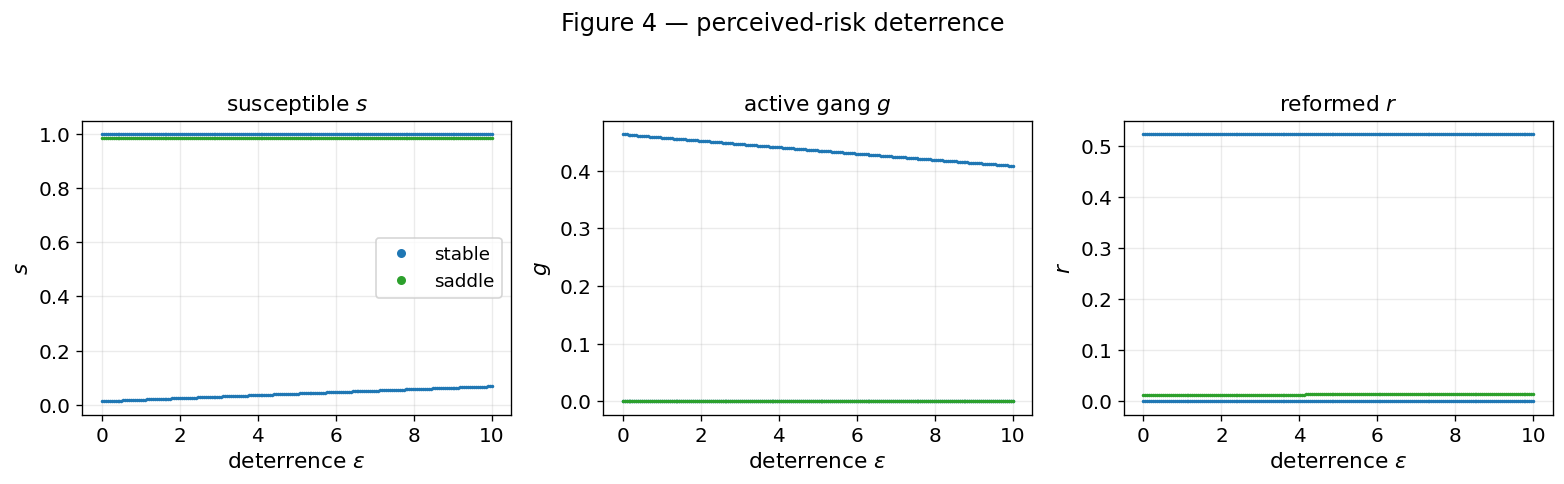

  saddle-node(s) at eps = none


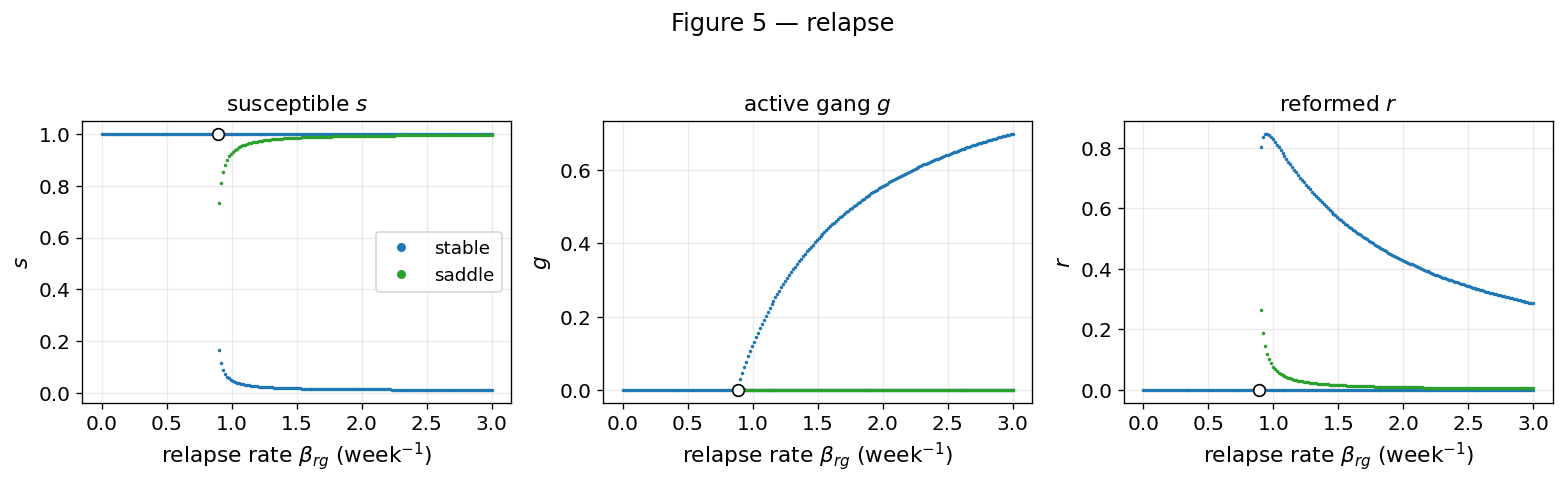

  saddle-node(s) at beta_rg = [0.8907]


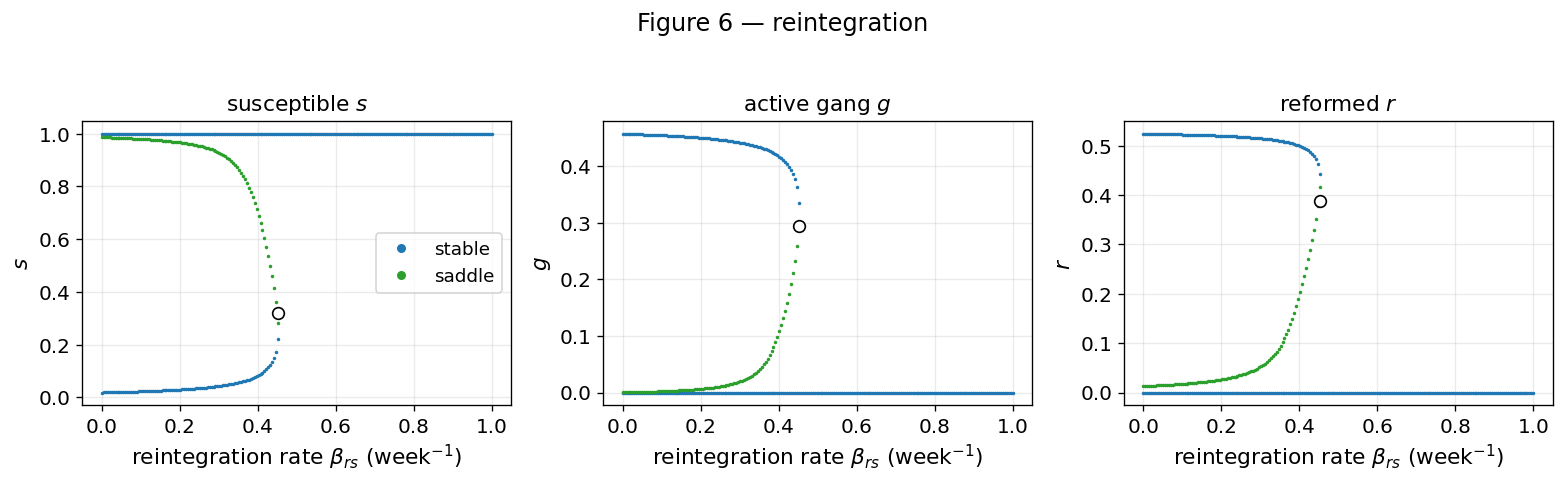

  saddle-node(s) at beta_rs = [0.4529]


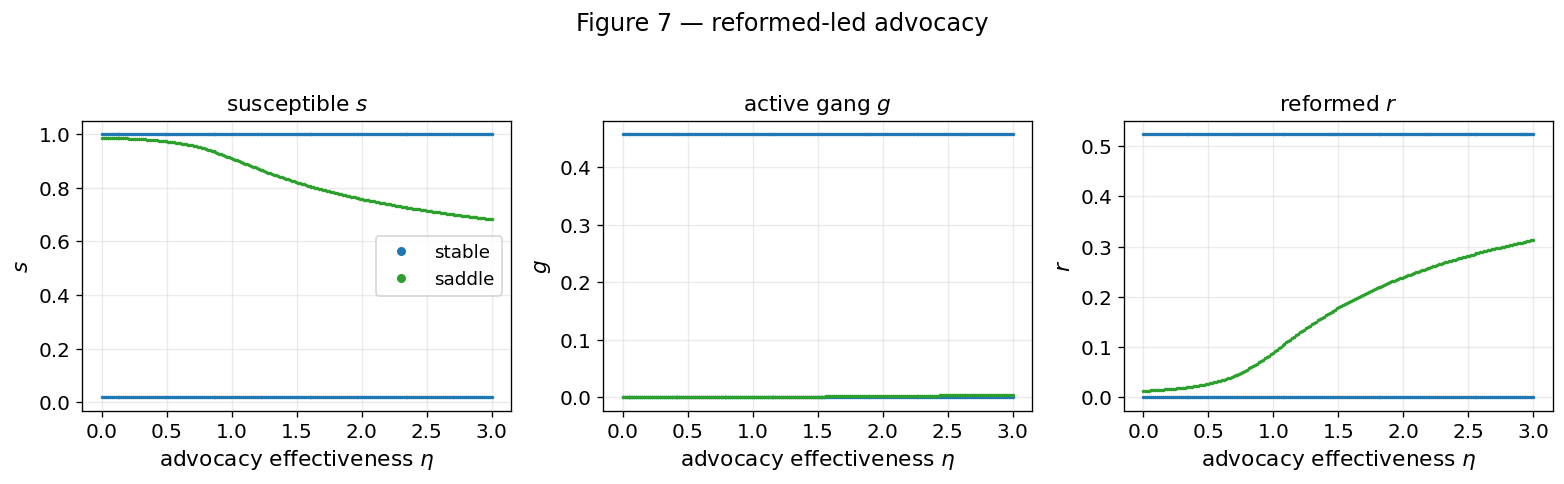

  saddle-node(s) at eta = none


In [5]:
_ = bifurcation_figure('eps', 0.0, 10.0,
        'Figure 4 — perceived-risk deterrence', 'fig04_deterrence')
_ = bifurcation_figure('beta_rg', 0.0, 3.0,
        'Figure 5 — relapse', 'fig05_relapse')
_ = bifurcation_figure('beta_rs', 0.0, 1.0,
        'Figure 6 — reintegration', 'fig06_reintegration')
_ = bifurcation_figure('eta', 0.0, 3.0,
        'Figure 7 — reformed-led advocacy', 'fig07_advocacy')

## Summary

- The recruitment diagram shows a **backward bifurcation**: a stable high-gang
  equilibrium persists below the invasion threshold, over an interval spanning an order
  of magnitude in $\mathcal{R}_0^{\rm simp}$ (folding at $\beta_{sg} \approx 0.076$,
  threshold at $0.865$).
- Relapse and reintegration each produce a saddle-node ($\beta_{rg} \approx 0.890$,
  $\beta_{rs} \approx 0.453$).
- Deterrence and advocacy, **acting alone at this baseline, do not close the bistable
  interval**. Advocacy still matters: it acts at first order on the *threshold* itself,
  which is a different quantity from the equilibrium prevalence. Notebook 03 makes that
  distinction quantitative.

**Next:** `03_prcc_sensitivity.ipynb`.

**Revision history:** v1.0 initial release (2026-07).

In [6]:
# ── Download outputs ───────────────────────────────────────────────────────────
output_files = [f'figures/fig{n}.png' for n in
                ['03_recruitment', '04_deterrence', '05_relapse',
                 '06_reintegration', '07_advocacy']]
try:
    from google.colab import files
    for fname in output_files:
        files.download(fname)
    print("Downloads triggered.")
except ImportError:
    print("Not in Colab — files saved locally:")
    for fname in output_files:
        if os.path.exists(fname):
            print(f"  {fname}  ({os.path.getsize(fname) // 1024} KB)")

Not in Colab — files saved locally:
  figures/fig03_recruitment.png  (85 KB)
  figures/fig04_deterrence.png  (54 KB)
  figures/fig05_relapse.png  (66 KB)
  figures/fig06_reintegration.png  (65 KB)
  figures/fig07_advocacy.png  (61 KB)
